# Crawling detik.com

Dataset berisi **200 artikel** dari detik.com dengan pembagian **100 artikel
kategori sport** (id 1–100) dan **100 artikel kategori finance** (id 101–200).
Setiap baris terdiri atas kolom:

| Kolom | Keterangan |
|-------|------------|
| `id` | nomor urut artikel |
| `isi_berita` | teks utama artikel hasil ekstraksi trafilatura |
| `label` | kategori artikel (`sport` atau `finance`) |
| `url` | sumber tautan artikel |


## Crawling Ethics

Sebelum ber-_crawl_, perlu dipastikan dulu bahwa situs mengizinkannya. detik.com
menyediakan `robots.txt` publik di `https://www.detik.com/robots.txt`. Isi file
tersebut (diunduh pada tanggal pengerjaan notebook ini):

```text
User-agent: Googlebot
Disallow: */komentar$
Disallow: */main$
Disallow: */main/*
Disallow: /ajax/
Disallow: /api/
Disallow: /search/*
Disallow: /tag/news/*
Disallow: /tag/foto/*
Disallow: *?_ga
Disallow: *&sortby
Disallow: *&device=desktop
Disallow: */?
Disallow: *edu/pov/d-*
Disallow: /video/

User-agent: *
Allow: /
Sitemap: https://www.detik.com/sitemap.xml
```

Cara membacanya: baris `Disallow: ...` di atas hanya berlaku untuk `Googlebot`.
Untuk crawler umum (`User-agent: *`) hanya ada `Allow: /`, artinya seluruh situs
diizinkan untuk dijelajahi. detik.com bahkan menyediakan `Sitemap` resmi sebagai
sumber daftar URL. Berikut verifikasi langsung dari `robots.txt` tersebut.


In [1]:
import requests

ROBOTS_URL = "https://www.detik.com/robots.txt"
headers = {"User-Agent": "Mozilla/5.0 (compatible; PPWCrawler/1.0)"}
r = requests.get(ROBOTS_URL, headers=headers, timeout=30)
r.raise_for_status()
print("HTTP", r.status_code)


HTTP 200


In [2]:
lines = [ln for ln in r.text.splitlines() if ln.strip()]
for ln in lines:
    if ln.startswith(("User-agent:", "Allow:", "Sitemap:", "Disallow:")):
        print(ln)


User-agent: Googlebot
Disallow: */komentar$
Disallow: */main$
Disallow: */main/*
Disallow: /ajax/
Disallow: /api/
Disallow: /search/*
Disallow: /tag/news/*
Disallow: /tag/foto/*
Disallow: *?_ga
Disallow: *&sortby
Disallow: *&device=desktop
Disallow: */?
Disallow: *edu/pov/d-*
Disallow: /video/
User-agent: *
Allow: /
Sitemap: https://www.detik.com/sitemap.xml


Untuk `User-agent: *` tidak ada satu pun aturan `Disallow`, hanya `Allow: /`.
Artinya crawling dokumen diperbolehkan secara eksplisit. Sesuai etika, kami
tetap mengambil URL dari *sitemap* resmi, memberi jeda minimal 1 detik antar
permintaan, memakai User-Agent yang wajar, dan hanya menggunakan konten untuk
keperluan pembelajaran mata kuliah ini.


Karena data sudah tersedia di `data/crawling_detik.csv`, bagian ini tidak
mengulangi proses crawling melainkan memuat dan memeriksa kembali hasilnya.


In [3]:
import pandas as pd

df = pd.read_csv("data/crawling_detik.csv")
print(df.shape)


(200, 4)


In [4]:
df.head()


,id,isi_berita,label,url
0,1,Misi Indonesia untuk meloloskan tim 3x3 ke Oli...,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,Inilah daftar pelatih NBA terbaik sepanjang ma...,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,"Pelita Jaya mendapat dukungan ""tenaga"" baru un...",sport,https://sport.detik.com/basket/d-8353921/agar-...
3,4,Center Miami Heat Bam Adebayo mencetak 83 poin...,sport,https://sport.detik.com/basket/d-8395308/heat-...
4,5,Campus League 2026 Basketball Jakarta sudah me...,sport,https://sport.detik.com/basket/d-8512605/campu...


## Data Quality Check

Sebelum memakai dataset, perlu dipastikan strukturnya utuh: tidak ada nilai
yang hilang, tidak ada baris ganda, id urut dan lengkap, serta proporsi label
sesuai rencana.


In [5]:
df.isna().sum()


id            0
isi_berita    0
label         0
url           0
dtype: int64

In [6]:
print("Baris ganda:", df.duplicated().sum())
print("URL ganda:", df["url"].duplicated().sum())


Baris ganda: 0
URL ganda: 0


In [7]:
expected = pd.Series(range(1, len(df) + 1))
print("id lengkap:", df["id"].sort_values().equals(expected))


id lengkap: True


In [8]:
df["label"].value_counts()


label
sport      100
finance    100
Name: count, dtype: int64

Semua pemeriksaan lolos: tidak ada nilai kosong, tidak ada baris maupun URL
ganda, id terisi lengkap 1–200, dan pembagian label benar-benar 100 banding 100.


## Overview of the Articles

Berikut ringkasan panjang teks untuk melihat seberapa merata distribusi
panjang artikel antar kategori.


In [9]:
df["n_chars"] = df["isi_berita"].str.len()
df["n_words"] = df["isi_berita"].str.split().str.len()
df.groupby("label")[["n_chars", "n_words"]].describe().round(1)

n_chars                                                           \
          count    mean     std     min     25%     50%     75%      max   
label                                                                      
finance   100.0  2828.0  1629.5  1210.0  1888.8  2501.0  3234.0  14106.0   
sport     100.0  2557.1   903.2   924.0  1992.0  2409.0  2886.0   5809.0   

        n_words                                                    
          count   mean    std    min    25%    50%    75%     max  
label                                                              
finance   100.0  379.9  216.4  161.0  263.5  315.5  425.2  1930.0  
sport     100.0  365.3  128.2  144.0  280.5  339.0  405.2   801.0

Panjang artikel antar kategori cukup seimbang, dengan rata-rata sekitar
2.500 karakter atau 365 kata. Beberapa artikel finance lebih panjang dari
biasanya sehingga nilai maksimumnya cukup besar; ini wajar karena beberapa
berita memuat kutipan atau data pendukung yang panjang.

Berikut contoh isi untuk tiap kategori.


In [10]:
df[df["label"] == "sport"]["isi_berita"].iloc[0][:300]


'Misi Indonesia untuk meloloskan tim 3x3 ke Olimpiade mulai digencarkan. PP Perbasi menggandeng Nicolas Widmer, salah satu agensi 3x3 yang dipercaya FIBA.\nKerja sama itu diawali dengan menggelar workshop selama dua hari (4-5/8), di Kantor Perbasi, GBK Arena Senayan. Dengan tujuan, memetakan jalan Ind'

In [11]:
df[df["label"] == "finance"]["isi_berita"].iloc[0][:300]


'Direktorat Jenderal Pajak (DJP) menyampaikan sebanyak 38 wajib pajak (WP) di sektor besi dan baja telah masuk dalam berbagai tahapan penanganan per 26 Agustus 2026. Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa sebelumnya telah mengantongi daftar 40 perusahaan sektor baja yang diduga tidak patuh da'

## Brief Visualizations


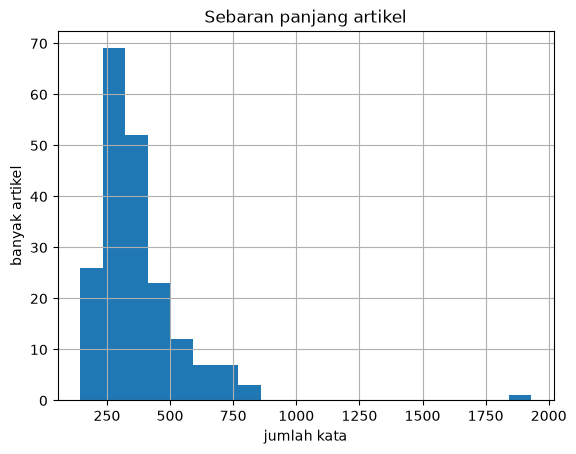

In [12]:
import matplotlib.pyplot as plt

df["n_words"].hist(bins=20)
plt.xlabel("jumlah kata")
plt.ylabel("banyak artikel")
plt.title("Sebaran panjang artikel")
plt.show()


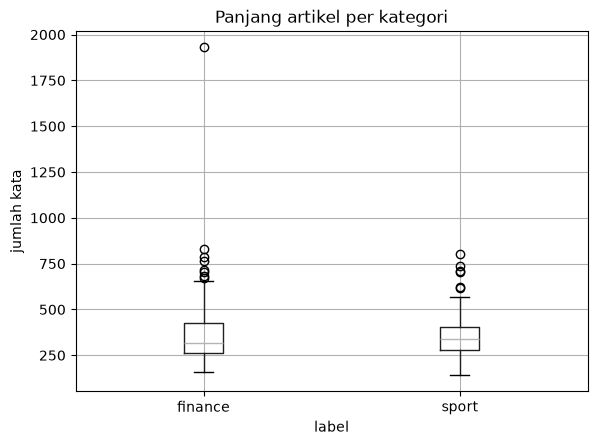

In [13]:
df.boxplot(column="n_words", by="label")
plt.suptitle("")
plt.title("Panjang artikel per kategori")
plt.ylabel("jumlah kata")
plt.show()


## Conclusion

Dataset Tugas 1 siap dipakai: 200 artikel terstruktur rapi dengan kolom
`id`, `isi_berita`, `label`, dan `url`, bebas dari nilai hilang, baris ganda,
maupun URL ganda. Panjang teks antar kategori relatif seimbang sehingga layak
dijadikan bahan untuk tahap kerja berikutnya.
